In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate as it
from scipy.interpolate import CubicSpline

In [38]:
def testfcn(t, m, amp_m, om_m, n, amp_n, om_n):
    return amp_m * np.sin(t * m * om_m ) + amp_n * np.sin(t * n * om_n)

In [39]:
duration = 1
fs = 2048
dt = 1.0 / fs

fmax = fs / 2
ntimes = duration // dt

m = 2
n = 10

amp_m = 1.0 - 1.0j
amp_n = 0.25 + 2.0j

period_m = duration / 4.0
period_n = duration / 10.0

om_m = 2. * np.pi / period_m
om_n = 2. * np.pi / period_n

times = np.arange(ntimes+1) * dt

In [40]:
data = testfcn(times, m, amp_m, om_m, n, amp_n, om_n)

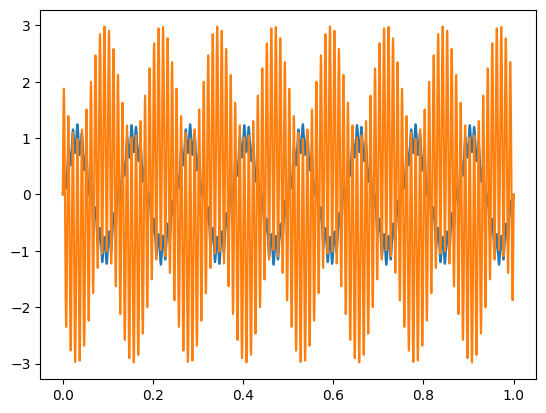

In [41]:
plt.plot(times, data.real)
plt.plot(times, data.imag)
plt.show()

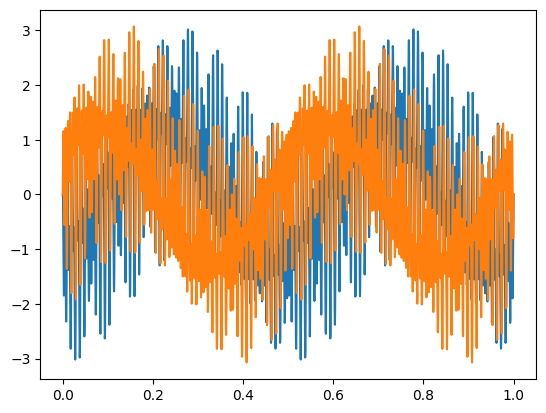

In [42]:
m_test = 2
n_test = 9
mode_mn = data * np.exp(1j * (m_test * om_m + n_test * om_n) * times)
plt.plot(times, mode_mn.real)
plt.plot(times, mode_mn.imag)
plt.show()

In [107]:
def py_amp(times, source_dict, mode_dict, method):
    m = source_dict['m']
    n = source_dict['n']
    amp_m = source_dict['amp_m']
    amp_n = source_dict['amp_n']
    period_m = source_dict['period_m']
    period_n = source_dict['period_n']
    om_m = 2. * np.pi / period_m
    om_n = 2. * np.pi / period_n

    data = testfcn(times, m, amp_m, om_m, n, amp_n, om_n)

    mode_n = mode_dict['n']
    mode_mn = data * np.exp(-1j * (mode_n * om_n) * times)
    
    if method == "trapezoid":
        I = np.trapezoid(mode_mn.real, x=times) + 1j*np.trapezoid(mode_mn.imag, x=times)
    elif method == "simpson":
        I = it.simpson(mode_mn.real, x=times) + 1j*it.simpson(mode_mn.imag, x=times)
    elif method == "cubic":
        I = (CubicSpline(times, mode_mn.real).integrate(times[0], times[-1])
             + 1j*CubicSpline(times, mode_mn.imag).integrate(times[0], times[-1]))
    return data, I / times[-1]

In [108]:
source_dict = {
    'm':2,
    'n':2,
    'amp_m':1.0 - 0.25j,
    'amp_n':0.25 + 0.25j,
    'period_m': duration / 2.0,
    'period_n': duration
}

mode_dict = {
    'n':2
}

py_amp(times, source_dict, mode_dict, 'simpson')

(array([ 0.00000000e+00+0.00000000e+00j,  1.38055094e-02-1.53391341e-03j,
         2.76091131e-02-3.06742256e-03j, ...,
        -2.76091131e-02+3.06742256e-03j, -1.38055094e-02+1.53391341e-03j,
        -1.10218212e-15+1.22464680e-16j], shape=(2049,)),
 np.complex128(0.125-0.125j))

In [109]:
mode_data = []
for n in range(-20,21):
    mode_dict['n'] = n
    data, nmode = py_amp(times, source_dict, mode_dict, 'simpson')
    mode_data.append([n, nmode])

md = np.array(mode_data)

/home/jonathan/.local/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jonathan/.local/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


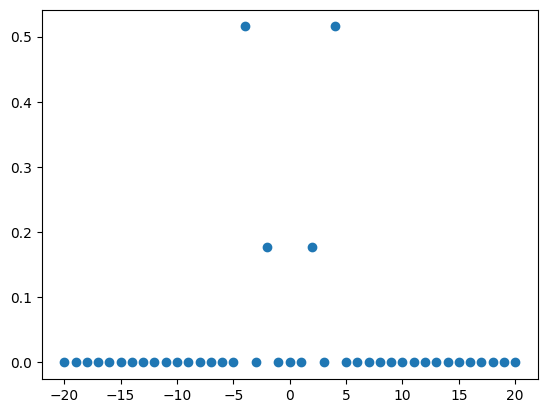

In [115]:
plt.scatter(md.T[0], np.abs(md.T[1]))

In [111]:
om_n = 2. * np.pi / source_dict['period_n']

t_reconstruct = np.sum(
    np.array([
        a * np.exp(1j*n*om_n*times)
        for n, a in md
    ]), axis=0
)

In [112]:
t_reconstruct

array([-6.35559314e-16+1.91578524e-16j,  1.38055094e-02-1.53391341e-03j,
        2.76091131e-02-3.06742256e-03j, ...,
       -2.76091131e-02+3.06742256e-03j, -1.38055094e-02+1.53391341e-03j,
       -1.74578234e-15+3.02600826e-16j], shape=(2049,))

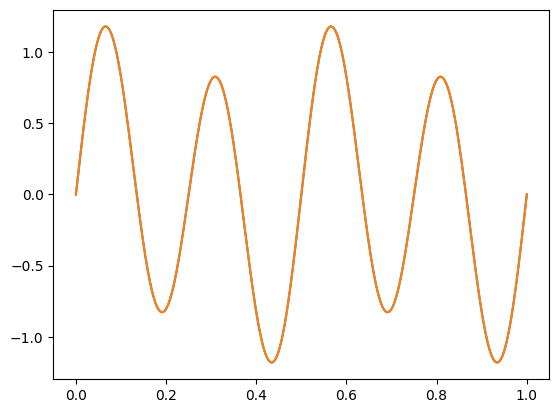

In [113]:
plt.plot(times, t_reconstruct.real)
plt.plot(times, data.real)

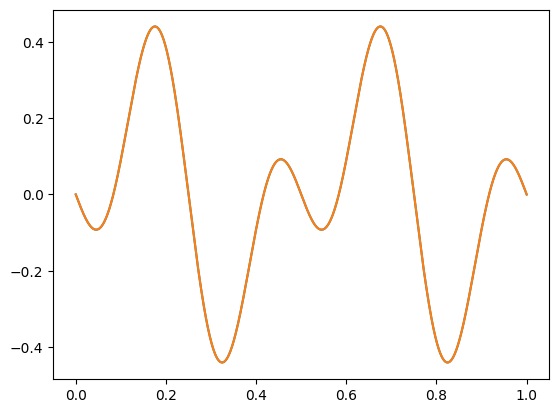

In [114]:
plt.plot(times, t_reconstruct.imag)
plt.plot(times, data.imag)